BLOC 1 — Imports et configuration

In [13]:
import os
import pandas as pd
import numpy as np
import sqlite3
import logging
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
log = logging.getLogger(__name__)

BASE        = Path(r"C:\Users\NIAMBELE Siata\Desktop\MSPR2")
MASTER_CSV  = BASE / "03_processed" / "master_ml.csv"
DB_PATH = BASE / "03_database" / "mspr2.db"
MODELS_DIR  = BASE / "04_outputs"   / "models"
OUTPUTS_DIR = BASE / "04_outputs"   / "ml"
RAW_SOCIO   = BASE / "01_raw"       / "socioeco"

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

REGROUPEMENT = {
    "Extreme gauche"      : "Gauche",
    "Gauche radicale"     : "Gauche",
    "Gauche"              : "Gauche",
    "Ecologie"            : "Gauche",
    "Centre"              : "Centre",
    "Droite"              : "Droite",
    "Droite souverainiste": "Droite",
    "Extreme droite"      : "Extreme droite",
    "Divers"              : "Divers",
    "Inconnu"             : "Divers",
}

COLS_SOCIO = [
    "population", "densite", "superficie_km2",
    "nb_logements", "nb_residences_principales", "nb_logements_vacants",
    "actifs_2022", "chomeurs_2022", "actifs_occupes_2022", "inactifs_2022",
    "taux_chomage_2022", "revenu_median", "taux_pauvrete",
    "part_chomeurs", "part_foyers_imposes",
    "d1_revenu", "d9_revenu", "ratio_interdecile",
    "nb_immigres", "nb_non_immigres", "total_delits",
    "nb_menages", "nb_personnes_menages"
]

COLS_EURO = [
    "euro_centre_ratio", "euro_divers_ratio", "euro_droite_ratio",
    "euro_extreme_droite_ratio", "euro_extreme_gauche_ratio",
    "euro_gauche_ratio", "euro_gauche_radicale_ratio",
    "euro_droite_souverainiste_ratio", "euro_ecologie_ratio",
    "euro_taux_participation"
]

CODE_DEPT = "69"

BLOC 2 — Chargement du master

In [14]:
if MASTER_CSV.exists():
    df = pd.read_csv(MASTER_CSV, sep=";", low_memory=False)
else:
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql("SELECT * FROM export_final", conn)
    conn.close()

df["famille_regroupee"] = df["famille_gagnante"].map(REGROUPEMENT).fillna("Divers")

print("Distribution par election et famille regroupee :")
print(df.groupby(["id_election", "famille_regroupee"]).size().unstack(fill_value=0).to_string())

Distribution par election et famille regroupee :
famille_regroupee  Centre  Droite  Extreme droite  Gauche
id_election                                              
2017_legi_t1          199      80               1       0
2017_pres_t1           72      95             103      10
2022_legi_t1          150      74              17      26
2022_pres_t1          186       0              66      15
2024_legi_t1           41      12             187      26


BLOC 3 — Calcul des deltas socioéco (2017 → 2022)

In [15]:
# --- Revenus : Filosofi 2017 -> 2021 ---
df_filo17 = pd.read_csv(
    RAW_SOCIO / "cc_filosofi_2017_COM.CSV",
    sep=";", dtype={"CODGEO": str}, low_memory=False
)
df_filo17 = df_filo17[df_filo17["CODGEO"].str.startswith(CODE_DEPT)].copy()
df_filo17 = df_filo17.rename(columns={
    "CODGEO": "code_commune", "MED17": "revenu_median_2017",
    "TP6017": "taux_pauvrete_2017", "RD17": "ratio_interdecile_2017",
    "D117"  : "d1_revenu_2017",    "D917": "d9_revenu_2017",
})[["code_commune", "revenu_median_2017", "taux_pauvrete_2017",
    "ratio_interdecile_2017", "d1_revenu_2017", "d9_revenu_2017"]]
for col in df_filo17.columns[1:]:
    df_filo17[col] = pd.to_numeric(df_filo17[col], errors="coerce")

df_filo21 = pd.read_excel(
    RAW_SOCIO / "FILO2021_DISP_COM.xlsx",
    sheet_name="ENSEMBLE", engine="calamine", header=5, dtype=str
)
df_filo21 = df_filo21[df_filo21["CODGEO"].astype(str).str.startswith(CODE_DEPT)].copy()
df_filo21 = df_filo21.rename(columns={"CODGEO": "code_commune", "Q221": "revenu_median_2021"})[
    ["code_commune", "revenu_median_2021"]
]
df_filo21["revenu_median_2021"] = pd.to_numeric(
    df_filo21["revenu_median_2021"].astype(str)
    .str.replace(",", ".").str.strip().replace("s", float("nan")),
    errors="coerce"
)

df_delta_revenus = df_filo17.merge(df_filo21, on="code_commune", how="inner")
df_delta_revenus["delta_revenu_median"]     = df_delta_revenus["revenu_median_2021"] - df_delta_revenus["revenu_median_2017"]
df_delta_revenus["pct_delta_revenu_median"] = (df_delta_revenus["delta_revenu_median"] / df_delta_revenus["revenu_median_2017"] * 100).round(2)
print(f"Deltas revenus : {len(df_delta_revenus):,} communes")

# --- Population : 2016 -> 2022 ---
df_pop = pd.read_csv(RAW_SOCIO / "population.CSV", sep=";", dtype={"CODGEO": str}, low_memory=False)
df_pop = df_pop[df_pop["CODGEO"].str.startswith(CODE_DEPT)].copy()
cols_pop = {"CODGEO": "code_commune", "P22_POP": "population_2022", "P16_POP": "population_2016",
            "P22_LOG": "nb_logements_2022", "P16_LOG": "nb_logements_2016", "SUPERF": "superficie_km2"}
cols_presentes = {k: v for k, v in cols_pop.items() if k in df_pop.columns}
df_pop = df_pop[list(cols_presentes.keys())].rename(columns=cols_presentes).copy()
for col in df_pop.columns[1:]:
    df_pop[col] = pd.to_numeric(df_pop[col], errors="coerce")
df_pop["densite_2022"]          = (df_pop["population_2022"] / df_pop["superficie_km2"]).round(2)
df_pop["densite_2016"]          = (df_pop["population_2016"] / df_pop["superficie_km2"]).round(2)
df_pop["delta_population"]      = df_pop["population_2022"]   - df_pop["population_2016"]
df_pop["pct_delta_population"]  = (df_pop["delta_population"] / df_pop["population_2016"] * 100).round(2)
df_pop["delta_densite"]         = (df_pop["densite_2022"] - df_pop["densite_2016"]).round(2)
df_pop["delta_nb_logements"]    = df_pop["nb_logements_2022"] - df_pop["nb_logements_2016"]
df_pop["pct_delta_nb_logements"]= (df_pop["delta_nb_logements"] / df_pop["nb_logements_2016"] * 100).round(2)
df_delta_pop = df_pop[["code_commune", "delta_population", "pct_delta_population",
                        "delta_densite", "delta_nb_logements", "pct_delta_nb_logements"]].copy()
print(f"Deltas population : {len(df_delta_pop):,} communes")

# --- Immigration : 2017 -> 2022 ---
df_imm17 = pd.read_csv(RAW_SOCIO / "BTT_TD_IMG1A_2017.CSV", sep=";", dtype=str, low_memory=False)
df_imm17 = df_imm17[(df_imm17["NIVGEO"] == "COM") & (df_imm17["CODGEO"].str.startswith(CODE_DEPT))].copy()
df_imm17["NB"] = pd.to_numeric(df_imm17["NB"], errors="coerce").fillna(0)
df_imm17 = (df_imm17.groupby(["CODGEO", "IMMI"])["NB"].sum().reset_index()
            .pivot(index="CODGEO", columns="IMMI", values="NB").reset_index())
df_imm17.columns.name = None
df_imm17 = df_imm17.rename(columns={"CODGEO": "code_commune", "1": "nb_immigres_2017", "2": "nb_non_immigres_2017"})

df_imm22 = pd.read_excel(RAW_SOCIO / "TD_IMG1A_2022.xlsx", sheet_name="COM",
                          engine="calamine", header=10, dtype={"CODGEO": str})
df_imm22 = df_imm22[df_imm22["CODGEO"].str.startswith(CODE_DEPT)].copy()
cols_immi1 = [c for c in df_imm22.columns if "IMMI1" in str(c)]
cols_immi2 = [c for c in df_imm22.columns if "IMMI2" in str(c)]
for col in cols_immi1 + cols_immi2:
    df_imm22[col] = pd.to_numeric(df_imm22[col], errors="coerce").fillna(0)
df_imm22 = pd.DataFrame({
    "code_commune"        : df_imm22["CODGEO"],
    "nb_immigres_2022"    : df_imm22[cols_immi1].sum(axis=1).round(0),
    "nb_non_immigres_2022": df_imm22[cols_immi2].sum(axis=1).round(0),
})

df_delta_imm = df_imm17.merge(df_imm22, on="code_commune", how="inner")
df_delta_imm["delta_nb_immigres"]     = df_delta_imm["nb_immigres_2022"] - df_delta_imm["nb_immigres_2017"]
df_delta_imm["pct_delta_nb_immigres"] = (df_delta_imm["delta_nb_immigres"] / df_delta_imm["nb_immigres_2017"] * 100).round(2)
df_delta_imm = df_delta_imm[["code_commune", "delta_nb_immigres", "pct_delta_nb_immigres"]].copy()
print(f"Deltas immigration : {len(df_delta_imm):,} communes")

# --- Sécurité : 2017 -> 2022 ---
FICHIERS_SECURITE = {
    "cambriolages"             : RAW_SOCIO / "ssmsi" / "ssmsi_cambriolages.csv",
    "destructions"             : RAW_SOCIO / "ssmsi" / "ssmsi_destructions.csv",
    "escroqueries"             : RAW_SOCIO / "ssmsi" / "ssmsi_escroqueries.csv",
    "trafic_stupefiants"       : RAW_SOCIO / "ssmsi" / "ssmsi_trafic_stupefiants.csv",
    "usage_stupefiants"        : RAW_SOCIO / "ssmsi" / "ssmsi_usage_stupefiants.csv",
    "violences_hors_famille"   : RAW_SOCIO / "ssmsi" / "ssmsi_violences_hors_famille.csv",
    "violences_intrafamiliales": RAW_SOCIO / "ssmsi" / "ssmsi_violences_intrafamiliales.csv",
    "violences_sexuelles"      : RAW_SOCIO / "ssmsi" / "ssmsi_violences_sexuelles.csv",
    "vols_accessoires"         : RAW_SOCIO / "ssmsi" / "ssmsi_vols_accessoires.csv",
    "vols_avec_armes"          : RAW_SOCIO / "ssmsi" / "ssmsi_vols_avec_armes.csv",
    "vols_dans_vehicules"      : RAW_SOCIO / "ssmsi" / "ssmsi_vols_dans_vehicules.csv",
    "vols_sans_armes"          : RAW_SOCIO / "ssmsi" / "ssmsi_vols_sans_armes.csv",
    "vols_sans_violence"       : RAW_SOCIO / "ssmsi" / "ssmsi_vols_sans_violence.csv",
    "vols_vehicule"            : RAW_SOCIO / "ssmsi" / "ssmsi_vols_vehicule.csv",
}
morceaux_sec = []
for type_delit, chemin in FICHIERS_SECURITE.items():
    df_s = pd.read_csv(chemin, dtype={"Code commune": str})
    masque = df_s["Code commune"].str.startswith(CODE_DEPT) & df_s["Année"].isin([2017, 2022])
    df_s = df_s[masque].copy()
    df_s["Nombre diffusé"] = df_s["Nombre diffusé"].fillna(0)
    df_s = df_s.rename(columns={"Code commune": "code_commune", "Année": "annee", "Nombre diffusé": "nombre"})[
        ["code_commune", "annee", "nombre"]
    ]
    morceaux_sec.append(df_s)

df_sec = (pd.concat(morceaux_sec, ignore_index=True)
          .groupby(["code_commune", "annee"])["nombre"].sum().reset_index()
          .rename(columns={"nombre": "total_delits"}))
df_sec_2017 = df_sec[df_sec["annee"] == 2017][["code_commune", "total_delits"]].rename(columns={"total_delits": "total_delits_2017"})
df_sec_2022 = df_sec[df_sec["annee"] == 2022][["code_commune", "total_delits"]].rename(columns={"total_delits": "total_delits_2022"})
df_delta_sec = df_sec_2017.merge(df_sec_2022, on="code_commune", how="inner")
df_delta_sec["delta_total_delits"]     = df_delta_sec["total_delits_2022"] - df_delta_sec["total_delits_2017"]
df_delta_sec["pct_delta_total_delits"] = (df_delta_sec["delta_total_delits"] / df_delta_sec["total_delits_2017"].replace(0, np.nan) * 100).round(2)
df_delta_sec = df_delta_sec[["code_commune", "delta_total_delits", "pct_delta_total_delits"]].copy()
print(f"Deltas sécurité : {len(df_delta_sec):,} communes")

# --- Fusion de tous les deltas ---
df_deltas = df_delta_revenus[["code_commune", "delta_revenu_median", "pct_delta_revenu_median", "taux_pauvrete_2017"]].copy()
for df_join in [df_delta_pop, df_delta_imm, df_delta_sec]:
    df_deltas = df_deltas.merge(df_join, on="code_commune", how="left")
for col in df_deltas.columns[1:]:
    df_deltas[col] = pd.to_numeric(df_deltas[col], errors="coerce")
    if df_deltas[col].isna().sum() > 0:
        df_deltas[col] = df_deltas[col].fillna(df_deltas[col].median())

df_deltas["code_commune"] = df_deltas["code_commune"].astype(str).str.strip()
print(f"\nTable deltas finale : {len(df_deltas):,} communes | {df_deltas.shape[1]} colonnes")
print(f"NaN restants : {df_deltas.isna().sum().sum()}")

Deltas revenus : 276 communes
Deltas population : 275 communes
Deltas immigration : 265 communes
Deltas sécurité : 275 communes

Table deltas finale : 276 communes | 13 colonnes
NaN restants : 0


BLOC 4 — Construction du master ML

In [16]:
def extraire_scores_election(df, id_election, suffixe):
    df_elec = df[df["id_election"] == id_election][
        ["code_commune", "famille_regroupee"] + COLS_SOCIO + COLS_EURO
    ].copy()
    rename = {"famille_regroupee": f"famille_{suffixe}"}
    for col in COLS_EURO:
        rename[col] = f"{col}_{suffixe}"
    for col in COLS_SOCIO:
        rename[col] = f"{col}_{suffixe}"
    return df_elec.rename(columns=rename)

df_2017_legi = extraire_scores_election(df, "2017_legi_t1", "legi_2017")
df_2017_pres = extraire_scores_election(df, "2017_pres_t1", "pres_2017")
df_2022_legi = extraire_scores_election(df, "2022_legi_t1", "legi_2022")
df_2022_pres = extraire_scores_election(df, "2022_pres_t1", "pres_2022")
df_2024_legi = extraire_scores_election(df, "2024_legi_t1", "legi_2024")

df_cible = df_2024_legi[["code_commune", "famille_legi_2024"]].copy()
df_cible = df_cible.rename(columns={"famille_legi_2024": "cible_2024"})

df_nouveau_master = df_cible.copy()
for df_elec, label in [
    (df_2017_legi, "legi_2017"),
    (df_2017_pres, "pres_2017"),
    (df_2022_legi, "legi_2022"),
    (df_2022_pres, "pres_2022"),
]:
    cols_a_joindre = ["code_commune"] + [c for c in df_elec.columns if c != "code_commune"]
    df_nouveau_master = df_nouveau_master.merge(df_elec[cols_a_joindre], on="code_commune", how="left")

for col in COLS_EURO:
    col_2017 = f"{col}_legi_2017"
    col_2022 = f"{col}_legi_2022"
    if col_2017 in df_nouveau_master.columns and col_2022 in df_nouveau_master.columns:
        df_nouveau_master[f"delta_{col}"] = df_nouveau_master[col_2022] - df_nouveau_master[col_2017]

df_nouveau_master["code_commune"] = df_nouveau_master["code_commune"].astype(str).str.strip()

print(f"Nouveau master : {len(df_nouveau_master):,} lignes | {df_nouveau_master.shape[1]} colonnes")
print(f"\nVariable cible - distribution :")
print(df_nouveau_master["cible_2024"].value_counts().to_string())

Nouveau master : 266 lignes | 148 colonnes

Variable cible - distribution :
cible_2024
Extreme droite    187
Centre             41
Gauche             26
Droite             12


BLOC 5 — Version 1 : Master complet

In [17]:
cols_exclure = ["code_commune", "cible_2024",
                "famille_legi_2017", "famille_pres_2017",
                "famille_legi_2022", "famille_pres_2022"]

X = df_nouveau_master[[c for c in df_nouveau_master.columns if c not in cols_exclure]].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")
for col in X.columns:
    if X[col].isna().sum() > 0:
        mediane = X[col].median()
        X[col]  = X[col].fillna(mediane if not pd.isna(mediane) else 0)

# Suppression des colonnes entièrement NaN
cols_a_supprimer = X.columns[X.isna().sum() > 0].tolist()
if cols_a_supprimer:
    X = X.drop(columns=cols_a_supprimer)
    print(f"Colonnes supprimées : {cols_a_supprimer}")

print(f"Features finales : {X.shape[1]}")

le_cible = LabelEncoder()
y = le_cible.fit_transform(df_nouveau_master["cible_2024"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {len(X_train)} | Test : {len(X_test)}")
print(f"Classes : {list(le_cible.classes_)}")

Features finales : 142
Train : 212 | Test : 54
Classes : ['Centre', 'Droite', 'Extreme droite', 'Gauche']


BLOC 6 — Définition et entraînement des modèles (Version 1)

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles = {
    "Random Forest": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")),
                               ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]),
        "params": {
            "clf__n_estimators"     : [100, 200, 300, 500],
            "clf__max_depth"        : [None, 5, 10, 20, 30],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf" : [1, 2, 4],
            "clf__max_features"     : ["sqrt", "log2", None],
            "clf__class_weight"     : [None, "balanced"],
        }
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")),
                               ("clf", GradientBoostingClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators"     : [100, 200, 300],
            "clf__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
            "clf__max_depth"        : [3, 5, 7, 10],
            "clf__subsample"        : [0.6, 0.8, 1.0],
            "clf__min_samples_split": [2, 5, 10],
            "clf__max_features"     : ["sqrt", "log2", None],
        }
    },
    "Logistic Regression": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")),
                               ("scaler", StandardScaler()),
                               ("clf", LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1))]),
        "params": {
            "clf__C"           : [0.001, 0.01, 0.1, 1, 10, 100],
            "clf__penalty"     : ["l1", "l2", "elasticnet"],
            "clf__solver"      : ["saga"],
            "clf__l1_ratio"    : [0.0, 0.25, 0.5, 0.75, 1.0],
            "clf__class_weight": [None, "balanced"],
        }
    },
    "KNN": {
        "pipeline": Pipeline([("imputer", SimpleImputer(strategy="median")),
                               ("scaler", StandardScaler()),
                               ("clf", KNeighborsClassifier(n_jobs=-1))]),
        "params": {
            "clf__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan", "minkowski"],
            "clf__p"          : [1, 2],
        }
    },
}

resultats = {}
for nom, config in modeles.items():
    log.info(f"Entrainement : {nom}...")
    search = RandomizedSearchCV(
        estimator=config["pipeline"], param_distributions=config["params"],
        n_iter=30, cv=skf, scoring="f1_weighted",
        n_jobs=-1, random_state=42, refit=True,
    )
    search.fit(X_train, y_train)
    resultats[nom] = {
        "modele"  : search.best_estimator_,
        "params"  : search.best_params_,
        "score_cv": round(search.best_score_, 4),
    }
    log.info(f"  Score CV : {search.best_score_:.4f}")

bilan = []
for nom, res in resultats.items():
    y_pred = res["modele"].predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    bilan.append({"modele": nom, "accuracy": round(acc, 4),
                  "f1_weighted": round(f1, 4), "score_cv": res["score_cv"]})
    print(f"\n{nom}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  F1 weighted : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=le_cible.classes_, zero_division=0))

df_bilan = pd.DataFrame(bilan).sort_values("f1_weighted", ascending=False)
display(df_bilan)

2026-06-05 16:22:24 [INFO] Entrainement : Random Forest...
2026-06-05 16:23:21 [INFO]   Score CV : 0.8602
2026-06-05 16:23:21 [INFO] Entrainement : Gradient Boosting...
2026-06-05 16:25:22 [INFO]   Score CV : 0.8623
2026-06-05 16:25:22 [INFO] Entrainement : Logistic Regression...
2026-06-05 16:25:55 [INFO]   Score CV : 0.8319
2026-06-05 16:25:55 [INFO] Entrainement : KNN...
2026-06-05 16:25:57 [INFO]   Score CV : 0.8521



Random Forest
  Accuracy    : 0.8333
  F1 weighted : 0.8007
                precision    recall  f1-score   support

        Centre       1.00      0.75      0.86         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.82      0.97      0.89        38
        Gauche       0.67      0.40      0.50         5

      accuracy                           0.83        54
     macro avg       0.62      0.53      0.56        54
  weighted avg       0.79      0.83      0.80        54


Gradient Boosting
  Accuracy    : 0.7963
  F1 weighted : 0.7678
                precision    recall  f1-score   support

        Centre       0.86      0.75      0.80         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.81      0.92      0.86        38
        Gauche       0.50      0.40      0.44         5

      accuracy                           0.80        54
     macro avg       0.54      0.52      0.53        54
  weighted avg       0.75    

,modele,accuracy,f1_weighted,score_cv
2,Logistic Regression,0.8519,0.8230,0.8319
0,Random Forest,0.8333,0.8007,0.8602
1,Gradient Boosting,0.7963,0.7678,0.8623
3,KNN,0.7778,0.7495,0.8521


BLOC 7 — Version 2 : Deltas seuls

In [19]:
df_model_v2 = df_nouveau_master[["code_commune", "cible_2024"]].copy()
df_model_v2 = df_model_v2.merge(df_deltas, on="code_commune", how="left")

cols_deltas  = [c for c in df_model_v2.columns if c not in ["code_commune", "cible_2024"]]
X_deltas     = df_model_v2[cols_deltas].copy()
for col in X_deltas.columns:
    X_deltas[col] = pd.to_numeric(X_deltas[col], errors="coerce")

le_deltas = LabelEncoder()
y_deltas  = le_deltas.fit_transform(df_model_v2["cible_2024"].fillna("Divers"))

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_deltas, y_deltas, test_size=0.2, random_state=42, stratify=y_deltas
)
print(f"Features deltas : {X_deltas.shape[1]} | Train : {len(X_train_d)} | Test : {len(X_test_d)}")

modeles_deltas = {
    "Random Forest"     : Pipeline([("imputer", SimpleImputer(strategy="median")),
                                     ("clf", RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=10,
                                                                    min_samples_leaf=2, max_features="sqrt",
                                                                    class_weight="balanced", random_state=42, n_jobs=-1))]),
    "Gradient Boosting" : Pipeline([("imputer", SimpleImputer(strategy="median")),
                                     ("clf", GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                                                        subsample=0.8, min_samples_split=5,
                                                                        max_features="sqrt", random_state=42))]),
    "Logistic Regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                                      ("clf", LogisticRegression(C=1, penalty="l1", solver="saga",
                                                                  max_iter=1000, random_state=42, n_jobs=-1))]),
    "KNN"               : Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                                     ("clf", KNeighborsClassifier(n_neighbors=3, weights="distance",
                                                                   metric="manhattan", p=2, n_jobs=-1))]),
}

bilan_deltas = []
for nom, pipeline in modeles_deltas.items():
    scores_cv = cross_val_score(pipeline, X_train_d, y_train_d, cv=skf, scoring="f1_weighted", n_jobs=-1)
    pipeline.fit(X_train_d, y_train_d)
    y_pred = pipeline.predict(X_test_d)
    acc = accuracy_score(y_test_d, y_pred)
    f1  = f1_score(y_test_d, y_pred, average="weighted", zero_division=0)
    bilan_deltas.append({"modele": nom, "accuracy": round(acc, 4),
                          "f1_weighted": round(f1, 4), "score_cv": round(scores_cv.mean(), 4)})
    print(f"\n{nom} | Accuracy : {acc:.4f} | F1 : {f1:.4f} | CV : {scores_cv.mean():.4f}")
    print(classification_report(y_test_d, y_pred, target_names=le_deltas.classes_, zero_division=0))

df_bilan_deltas = pd.DataFrame(bilan_deltas).sort_values("f1_weighted", ascending=False)
display(df_bilan_deltas)

Features deltas : 12 | Train : 212 | Test : 54

Random Forest | Accuracy : 0.6667 | F1 : 0.6255 | CV : 0.7231
                precision    recall  f1-score   support

        Centre       0.29      0.25      0.27         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.73      0.87      0.80        38
        Gauche       0.50      0.20      0.29         5

      accuracy                           0.67        54
     macro avg       0.38      0.33      0.34        54
  weighted avg       0.60      0.67      0.63        54


Gradient Boosting | Accuracy : 0.7037 | F1 : 0.6164 | CV : 0.7527
                precision    recall  f1-score   support

        Centre       0.25      0.12      0.17         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.74      0.97      0.84        38
        Gauche       0.00      0.00      0.00         5

      accuracy                           0.70        54
     macro avg       0.25      0.2

,modele,accuracy,f1_weighted,score_cv
2,Logistic Regression,0.7778,0.7307,0.7536
0,Random Forest,0.6667,0.6255,0.7231
1,Gradient Boosting,0.7037,0.6164,0.7527
3,KNN,0.6481,0.5927,0.7237


BLOC 8 — Version 3 : Master + Deltas

In [20]:
df_master_combined = df_nouveau_master.merge(df_deltas, on="code_commune", how="left")
print(f"Master combined : {len(df_master_combined):,} lignes | {df_master_combined.shape[1]} colonnes")

cols_exclure_combined = ["code_commune", "cible_2024",
                          "famille_legi_2017", "famille_pres_2017",
                          "famille_legi_2022", "famille_pres_2022"]
X_combined = df_master_combined[[c for c in df_master_combined.columns if c not in cols_exclure_combined]].copy()
for col in X_combined.columns:
    X_combined[col] = pd.to_numeric(X_combined[col], errors="coerce")

le_combined = LabelEncoder()
y_combined  = le_combined.fit_transform(df_master_combined["cible_2024"].fillna("Divers"))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)
print(f"Features combined : {X_combined.shape[1]} | Train : {len(X_train_c)} | Test : {len(X_test_c)}")

modeles_combined = {
    "Random Forest"     : Pipeline([("imputer", SimpleImputer(strategy="median")),
                                     ("clf", RandomForestClassifier(n_estimators=200, max_depth=30, min_samples_split=10,
                                                                    min_samples_leaf=2, max_features="sqrt",
                                                                    class_weight="balanced", random_state=42, n_jobs=-1))]),
    "Gradient Boosting" : Pipeline([("imputer", SimpleImputer(strategy="median")),
                                     ("clf", GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                                                        subsample=0.8, min_samples_split=5,
                                                                        max_features="sqrt", random_state=42))]),
    "Logistic Regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                                      ("clf", LogisticRegression(C=1, penalty="l1", solver="saga",
                                                                  max_iter=1000, random_state=42, n_jobs=-1))]),
    "KNN"               : Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()),
                                     ("clf", KNeighborsClassifier(n_neighbors=3, weights="distance",
                                                                   metric="manhattan", p=2, n_jobs=-1))]),
}

bilan_combined = []
for nom, pipeline in modeles_combined.items():
    scores_cv = cross_val_score(pipeline, X_train_c, y_train_c, cv=skf, scoring="f1_weighted", n_jobs=-1)
    pipeline.fit(X_train_c, y_train_c)
    y_pred = pipeline.predict(X_test_c)
    acc = accuracy_score(y_test_c, y_pred)
    f1  = f1_score(y_test_c, y_pred, average="weighted", zero_division=0)
    bilan_combined.append({"modele": nom, "accuracy": round(acc, 4),
                            "f1_weighted": round(f1, 4), "score_cv": round(scores_cv.mean(), 4)})
    print(f"\n{nom} | Accuracy : {acc:.4f} | F1 : {f1:.4f} | CV : {scores_cv.mean():.4f}")
    print(classification_report(y_test_c, y_pred, target_names=le_combined.classes_, zero_division=0))

df_bilan_combined = pd.DataFrame(bilan_combined).sort_values("f1_weighted", ascending=False)
display(df_bilan_combined)

Master combined : 266 lignes | 160 colonnes
Features combined : 154 | Train : 212 | Test : 54

Random Forest | Accuracy : 0.8333 | F1 : 0.8007 | CV : 0.8502
                precision    recall  f1-score   support

        Centre       1.00      0.75      0.86         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.82      0.97      0.89        38
        Gauche       0.67      0.40      0.50         5

      accuracy                           0.83        54
     macro avg       0.62      0.53      0.56        54
  weighted avg       0.79      0.83      0.80        54


Gradient Boosting | Accuracy : 0.8519 | F1 : 0.8166 | CV : 0.8586
                precision    recall  f1-score   support

        Centre       1.00      0.75      0.86         8
        Droite       0.00      0.00      0.00         3
Extreme droite       0.83      1.00      0.90        38
        Gauche       1.00      0.40      0.57         5

      accuracy                           0.

,modele,accuracy,f1_weighted,score_cv
2,Logistic Regression,0.8704,0.8408,0.8288
1,Gradient Boosting,0.8519,0.8166,0.8586
0,Random Forest,0.8333,0.8007,0.8502
3,KNN,0.8333,0.7961,0.8328


In [21]:
import joblib

for nom, pipeline in modeles_combined.items():
    nom_fichier = nom.replace(" ", "_").lower()
    joblib.dump(pipeline, MODELS_DIR / f"{nom_fichier}_combined.joblib")
    print(f"Sauvegardé : {nom_fichier}_combined.joblib")

joblib.dump(le_combined,      MODELS_DIR / "le_combined.joblib")
joblib.dump(X_combined,       MODELS_DIR / "X_combined.pkl")
joblib.dump(X_train_c,        MODELS_DIR / "X_train_c.pkl")
joblib.dump(X_test_c,         MODELS_DIR / "X_test_c.pkl")
joblib.dump(y_combined,       MODELS_DIR / "y_combined.pkl")
joblib.dump(y_train_c,        MODELS_DIR / "y_train_c.pkl")
joblib.dump(y_test_c,         MODELS_DIR / "y_test_c.pkl")
joblib.dump(df_bilan_combined,MODELS_DIR / "df_bilan_combined.pkl")

print("\nTout sauvegardé dans", MODELS_DIR)

Sauvegardé : random_forest_combined.joblib
Sauvegardé : gradient_boosting_combined.joblib
Sauvegardé : logistic_regression_combined.joblib
Sauvegardé : knn_combined.joblib

Tout sauvegardé dans C:\Users\NIAMBELE Siata\Desktop\MSPR2\04_outputs\models


BLOC 9 — Comparaison des 3 versions + visualisations législatives

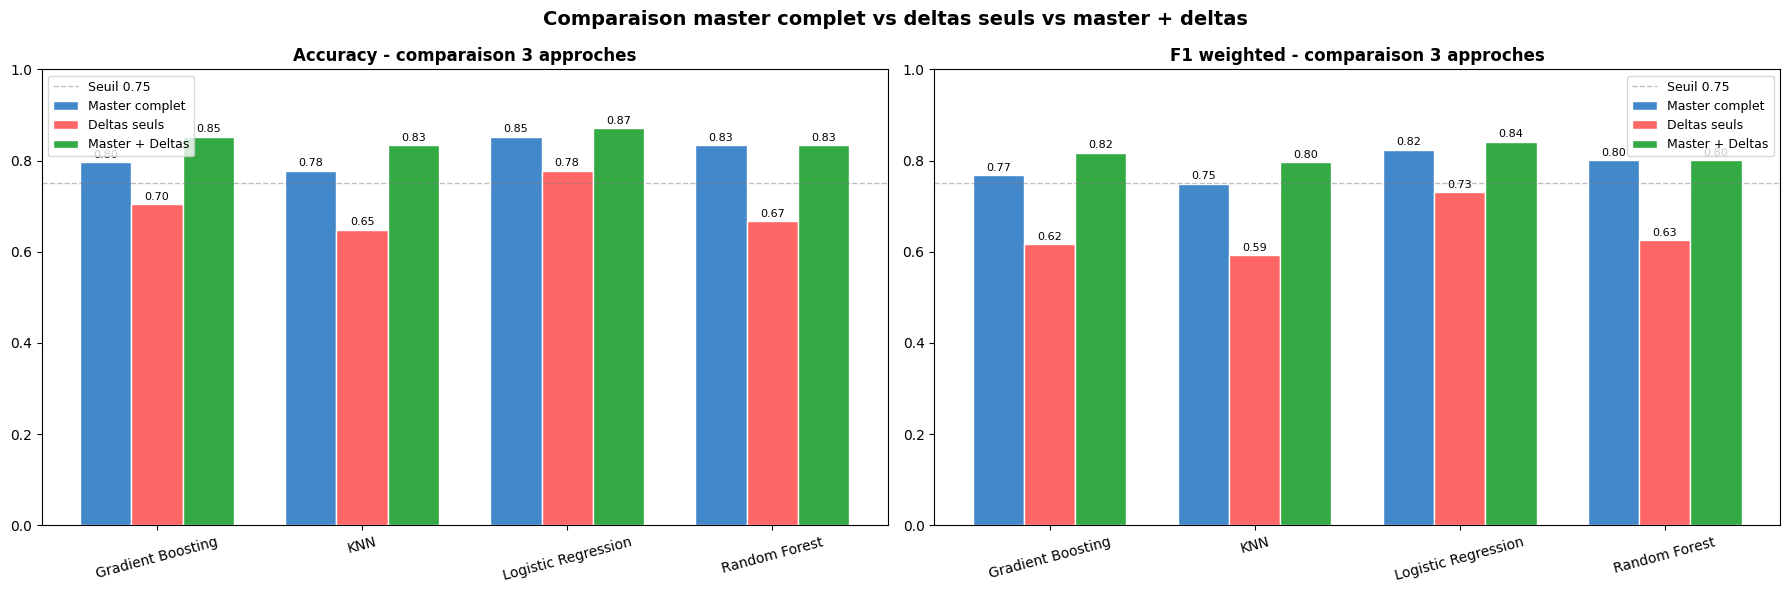


Accuracy globale : 0.9060


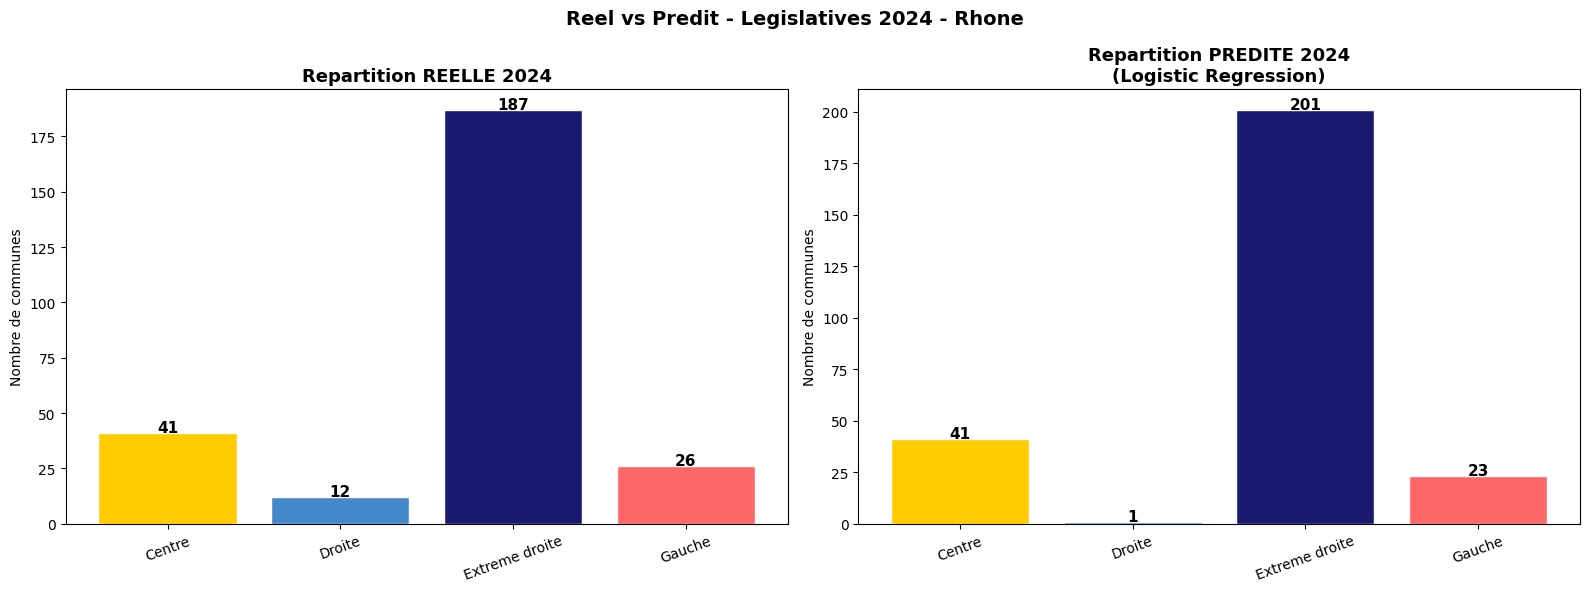

In [22]:
couleurs = {
    "Centre"        : "#FFCC00",
    "Droite"        : "#4488CC",
    "Extreme droite": "#1A1A6E",
    "Gauche"        : "#FF6666",
    "Divers"        : "#AAAAAA",
}

# Comparaison des 3 approches
df_v1 = df_bilan.copy();        df_v1["version"] = "Master complet"
df_v2 = df_bilan_deltas.copy(); df_v2["version"] = "Deltas seuls"
df_v3 = df_bilan_combined.copy();df_v3["version"] = "Master + Deltas"
df_comp_final = pd.concat([df_v1, df_v2, df_v3], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric, label in zip(axes, ["accuracy", "f1_weighted"], ["Accuracy", "F1 weighted"]):
    pivot = df_comp_final.pivot(index="modele", columns="version", values=metric)
    x, width = range(len(pivot)), 0.25
    for j, (version, color) in enumerate(zip(
        ["Master complet", "Deltas seuls", "Master + Deltas"],
        ["#4488CC", "#FF6666", "#33AA44"]
    )):
        if version not in pivot.columns: continue
        bars = ax.bar([i + j * width for i in x], pivot[version], width, label=version, color=color, edgecolor="white")
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{bar.get_height():.2f}", ha="center", fontsize=8)
    ax.set_title(f"{label} - comparaison 3 approches", fontsize=12, fontweight="bold")
    ax.set_xticks([i + width for i in x])
    ax.set_xticklabels(pivot.index, rotation=15)
    ax.set_ylim(0, 1)
    ax.axhline(y=0.75, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="Seuil 0.75")
    ax.legend(fontsize=9)
plt.suptitle("Comparaison master complet vs deltas seuls vs master + deltas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_comparaison_3_versions.png", bbox_inches="tight")
plt.show()

# Reel vs prédit 2024 avec le meilleur modèle combined
meilleur_nom_combined    = df_bilan_combined.iloc[0]["modele"]
meilleur_modele_combined = modeles_combined[meilleur_nom_combined]

y_pred_tout = meilleur_modele_combined.predict(X_combined)
df_master_combined["prediction_2024"] = le_combined.inverse_transform(y_pred_tout)
df_comparaison = df_master_combined[["code_commune", "cible_2024", "prediction_2024"]].copy()
df_comparaison["correct"] = df_comparaison["cible_2024"] == df_comparaison["prediction_2024"]
print(f"\nAccuracy globale : {df_comparaison['correct'].mean():.4f}")

familles_ordre = sorted(df_comparaison["cible_2024"].unique())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col_data, titre in zip(axes,
    ["cible_2024", "prediction_2024"],
    ["Repartition REELLE 2024", f"Repartition PREDITE 2024\n({meilleur_nom_combined})"]):
    vals = [df_comparaison[col_data].value_counts().get(f, 0) for f in familles_ordre]
    cols = [couleurs.get(f, "#AAAAAA") for f in familles_ordre]
    bars = ax.bar(familles_ordre, vals, color=cols, edgecolor="white")
    ax.set_title(titre, fontsize=13, fontweight="bold")
    ax.set_ylabel("Nombre de communes")
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha="center", fontsize=11, fontweight="bold")
plt.suptitle("Reel vs Predit - Legislatives 2024 - Rhone", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_reel_vs_predit_2024.png", bbox_inches="tight")
plt.show()

BLOC 10 — Sauvegarde du meilleur modèle

In [23]:
# BLOC 10 — Sauvegarde complète
import joblib

# Meilleur modèle
meilleur_nom_combined    = df_bilan_combined.iloc[0]["modele"]
meilleur_modele_combined = modeles_combined[meilleur_nom_combined]
joblib.dump(meilleur_modele_combined, MODELS_DIR / "meilleur_modele_combined.joblib")

# Tous les modèles entraînés
for nom, pipeline in modeles_combined.items():
    nom_fichier = nom.replace(" ", "_").lower()
    joblib.dump(pipeline, MODELS_DIR / f"{nom_fichier}_combined.joblib")
    print(f"Sauvegardé : {nom_fichier}_combined.joblib")

# Données
joblib.dump(le_combined,       MODELS_DIR / "le_combined.joblib")
joblib.dump(X_combined,        MODELS_DIR / "X_combined.pkl")
joblib.dump(X_train_c,         MODELS_DIR / "X_train_c.pkl")
joblib.dump(X_test_c,          MODELS_DIR / "X_test_c.pkl")
joblib.dump(y_combined,        MODELS_DIR / "y_combined.pkl")
joblib.dump(y_train_c,         MODELS_DIR / "y_train_c.pkl")
joblib.dump(y_test_c,          MODELS_DIR / "y_test_c.pkl")
joblib.dump(df_bilan_combined, MODELS_DIR / "df_bilan_combined.pkl")
joblib.dump(df_bilan,          MODELS_DIR / "df_bilan.pkl")
joblib.dump(df_bilan_deltas,   MODELS_DIR / "df_bilan_deltas.pkl")

# Bilan en base
conn = sqlite3.connect(DB_PATH)
df_bilan_combined_db = df_bilan_combined.copy()
df_bilan_combined_db["version"] = "master_combined"
df_bilan_combined_db.to_sql("bilan_combined", conn, if_exists="replace", index=False)
conn.close()

print(f"\nMeilleur modèle : {meilleur_nom_combined}")
print(f"Tout sauvegardé dans : {MODELS_DIR}")
display(df_bilan_combined)

Sauvegardé : random_forest_combined.joblib
Sauvegardé : gradient_boosting_combined.joblib
Sauvegardé : logistic_regression_combined.joblib
Sauvegardé : knn_combined.joblib

Meilleur modèle : Logistic Regression
Tout sauvegardé dans : C:\Users\NIAMBELE Siata\Desktop\MSPR2\04_outputs\models


,modele,accuracy,f1_weighted,score_cv
2,Logistic Regression,0.8704,0.8408,0.8288
1,Gradient Boosting,0.8519,0.8166,0.8586
0,Random Forest,0.8333,0.8007,0.8502
3,KNN,0.8333,0.7961,0.8328


BLOC 11 — Projection présidentielles 2027

Accuracy : 0.8889 | F1 : 0.8866 | CV : 0.8634
                precision    recall  f1-score   support

        Centre       0.90      0.95      0.92        38
Extreme droite       0.83      0.77      0.80        13
        Gauche       1.00      0.67      0.80         3

      accuracy                           0.89        54
     macro avg       0.91      0.79      0.84        54
  weighted avg       0.89      0.89      0.89        54

PROJECTION PRESIDENTIELLES 2027 - RHONE
  Centre                189 communes (70.8%) ############################
  Extreme droite         64 communes (24.0%) #########
  Gauche                 14 communes (5.2%) ##

Vainqueur predit 2027 : Centre


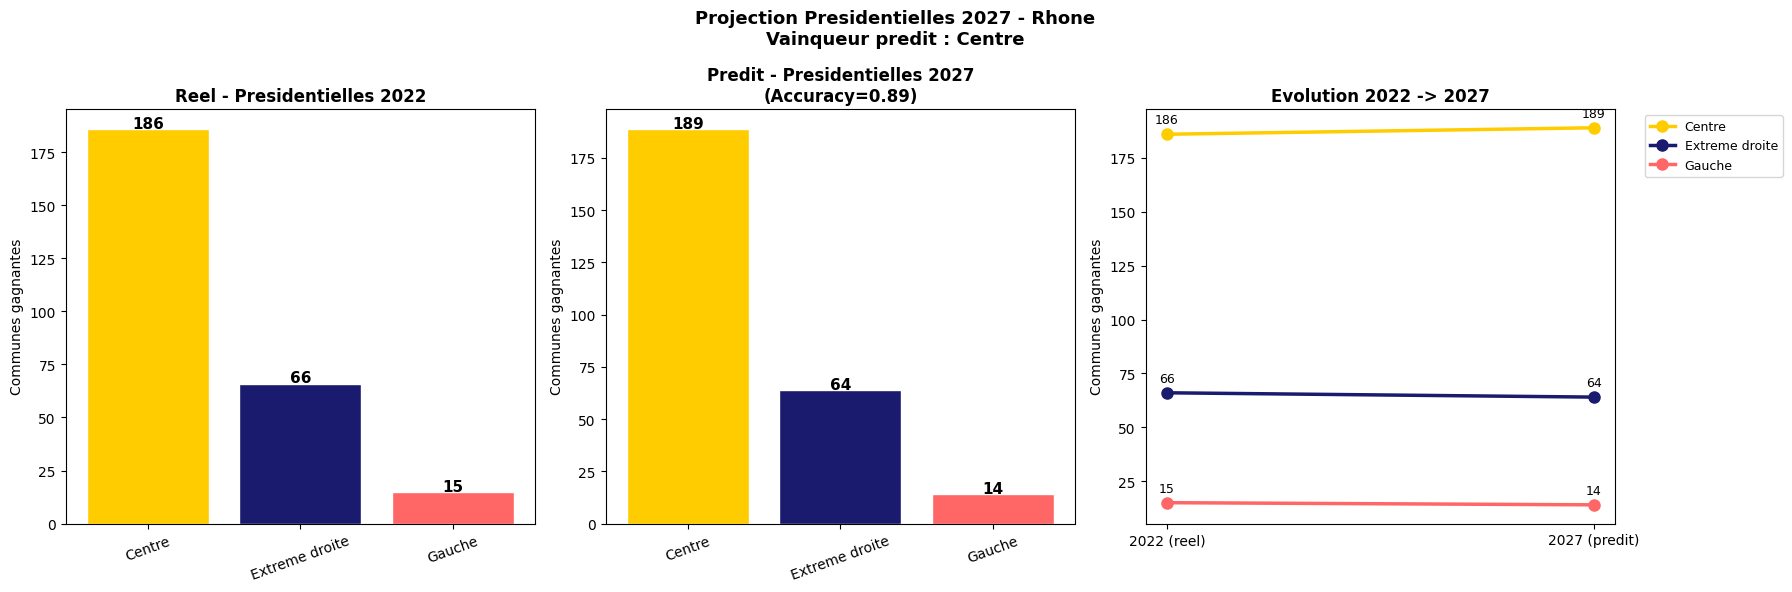


Note : projection indicative basée sur les données socioéconomiques 2017-2022
et les signaux électoraux les plus récents (législatives 2024).


In [24]:
df_pres_2017 = extraire_scores_election(df, "2017_pres_t1", "pres_2017")
df_pres_2022 = extraire_scores_election(df, "2022_pres_t1", "pres_2022")
df_legi_2024 = extraire_scores_election(df, "2024_legi_t1", "legi_2024")

df_master_2027 = df_pres_2022[["code_commune"]].copy()
df_master_2027 = df_master_2027.merge(df_pres_2017, on="code_commune", how="left")
df_master_2027 = df_master_2027.merge(df_pres_2022, on="code_commune", how="left", suffixes=("", "_dup"))
df_master_2027 = df_master_2027.drop(columns=[c for c in df_master_2027.columns if c.endswith("_dup")])
df_master_2027 = df_master_2027.merge(df_legi_2024, on="code_commune", how="left")

for col in COLS_EURO:
    col_2017, col_2022 = f"{col}_pres_2017", f"{col}_pres_2022"
    if col_2017 in df_master_2027.columns and col_2022 in df_master_2027.columns:
        df_master_2027[f"delta_pres_{col}"] = df_master_2027[col_2022] - df_master_2027[col_2017]

df_master_2027["code_commune"] = df_master_2027["code_commune"].astype(str).str.strip()
df_master_2027 = df_master_2027.merge(df_deltas, on="code_commune", how="left")
df_master_2027["cible_pres"]   = df_master_2027["famille_pres_2022"].map(REGROUPEMENT).fillna("Divers")

cols_exclure_2027   = ["code_commune", "cible_pres", "famille_pres_2017", "famille_pres_2022", "famille_legi_2024"]
cols_features_2027  = [c for c in df_master_2027.columns if c not in cols_exclure_2027]
X_2027 = df_master_2027[cols_features_2027].copy()
for col in X_2027.columns:
    X_2027[col] = pd.to_numeric(X_2027[col], errors="coerce")

le_2027 = LabelEncoder()
y_2027  = le_2027.fit_transform(df_master_2027["cible_pres"].fillna("Divers"))

X_train_2027, X_test_2027, y_train_2027, y_test_2027 = train_test_split(
    X_2027, y_2027, test_size=0.2, random_state=42, stratify=y_2027
)

pipeline_2027 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf", LogisticRegression(C=1, penalty="l1", solver="saga", max_iter=1000, random_state=42, n_jobs=-1))
])
scores_cv_2027 = cross_val_score(pipeline_2027, X_train_2027, y_train_2027,
                                  cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                                  scoring="f1_weighted", n_jobs=-1)
pipeline_2027.fit(X_train_2027, y_train_2027)

y_pred_val = pipeline_2027.predict(X_test_2027)
acc_2027   = accuracy_score(y_test_2027, y_pred_val)
f1_2027    = f1_score(y_test_2027, y_pred_val, average="weighted", zero_division=0)
print(f"Accuracy : {acc_2027:.4f} | F1 : {f1_2027:.4f} | CV : {scores_cv_2027.mean():.4f}")
print(classification_report(y_test_2027, y_pred_val, target_names=le_2027.classes_, zero_division=0))

# Projection
y_projection_2027 = pipeline_2027.predict(X_2027)
df_master_2027["prediction_2027"] = le_2027.inverse_transform(y_projection_2027)
projection_2027 = df_master_2027["prediction_2027"].value_counts()
total_2027      = len(df_master_2027)
vainqueur_2027  = projection_2027.index[0]

print("=" * 60)
print("PROJECTION PRESIDENTIELLES 2027 - RHONE")
print("=" * 60)
for famille, nb in projection_2027.items():
    barre = "#" * int(nb / total_2027 * 40)
    print(f"  {famille:<20} {nb:>4} communes ({nb/total_2027*100:.1f}%) {barre}")
print(f"\nVainqueur predit 2027 : {vainqueur_2027}")

# Visualisation
familles = sorted(set(list(df_master_2027["cible_pres"].unique()) + list(df_master_2027["prediction_2027"].unique())))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col_data, titre in zip(
    axes[:2],
    ["cible_pres", "prediction_2027"],
    ["Reel - Presidentielles 2022", f"Predit - Presidentielles 2027\n(Accuracy={acc_2027:.2f})"]
):
    vals = [df_master_2027[col_data].value_counts().get(f, 0) for f in familles]
    bars = axes[list(axes).index(ax)].bar(familles, vals, color=[couleurs.get(f, "#AAAAAA") for f in familles], edgecolor="white")
    ax.set_title(titre, fontsize=12, fontweight="bold")
    ax.set_ylabel("Communes gagnantes")
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha="center", fontsize=11, fontweight="bold")

for famille in familles:
    val_2022 = df_master_2027["cible_pres"].value_counts().get(famille, 0)
    val_2027 = projection_2027.get(famille, 0)
    axes[2].plot(["2022 (reel)", "2027 (predit)"], [val_2022, val_2027],
                  marker="o", label=famille, color=couleurs.get(famille, "#AAAAAA"), linewidth=2.5, markersize=8)
    for x_pt, y_pt in [("2022 (reel)", val_2022), ("2027 (predit)", val_2027)]:
        axes[2].annotate(str(y_pt), (x_pt, y_pt), textcoords="offset points",
                          xytext=(0, 8), ha="center", fontsize=9)
axes[2].set_title("Evolution 2022 -> 2027", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Communes gagnantes")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.suptitle(f"Projection Presidentielles 2027 - Rhone\nVainqueur predit : {vainqueur_2027}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ml_projection_pres_2027_final.png", bbox_inches="tight")
plt.show()

print("\nNote : projection indicative basée sur les données socioéconomiques 2017-2022")
print("et les signaux électoraux les plus récents (législatives 2024).")